# Cross-Session Transfer Training

Train a stim→spike CNN with a **shared backbone** and **per-session input
adapters + projection heads**, then measure how many target-session patterns
are needed to finetune to a held-out accuracy.

**Sessions**

| key | path | stim ch | neurons | oracles |
|---|---|---|---|---|
| `vis_stim` | `vis_stim/data/` | 40 | 72 | 100×10 |
| `icms150`  | `patterns_5k/data/oracle_ICMS_150/` | 42 | 71 | 50×20 |
| `icms148`  | `patterns_5k/data/original_ICMS_148/` | 44 | 47 | **none** |

`icms148` has no repeated (oracle) patterns, so it can **never** be the held-out
evaluation target — this is asserted in the code.

Architecture: per-session `Conv1d(n_ch -> COMMON_CH, kernel=1)` adapter → shared
`conv_stack` backbone → per-session `fc` head. See
`docs/superpowers/specs/2026-05-31-cross-session-training-design.md`.

In [2]:
# --- setup ---
import os, sys, json, time, copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset

sys.path.insert(0, '../patterns_5k')
from utils import (read_pattern_json, preprocess_pattern_stimulations_df,
                   trial_breakout_spikes_and_patterns, BinnedStimSpikeDataset)
from models import SimpleCausalSpikeCNN
from metrics import compute_correlation

%load_ext autoreload
%autoreload 2

device = torch.device('cuda' if torch.cuda.is_available() else
                      'mps'  if torch.backends.mps.is_available() else 'cpu')
print('device:', device)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
device: cuda


In [ ]:
# --- experiment config ---
# SOURCE/TARGET are chosen per run. TARGET must have oracle patterns (not icms148).
CFG_XS = dict(
    SOURCE = 'icms150',          # pretraining session
    TARGET = 'vis_stim',         # finetuning target (asserted != 'icms148')
    COMMON_CH = 128,              # shared backbone input width (try 64 over-complete later)

    # --- source pretraining ---
    N_TRAIN_EXAMPLES = None,     # cap on # source non-oracle training patterns (None = all)

    # --- evaluation ---
    EVAL_USE_SINGLE_TRIALS = False,  # fold single-trial held-out patterns into eval set too

    # --- finetuning data-efficiency sweep ---
    FINETUNE_N_GRID = [10, 25, 50, 100, 250, 500],
    PROTOCOLS = ['frozen_backbone', 'full_finetune', 'from_scratch'],
    SEEDS = [0, 1, 2],

    # --- temporal binning (matches the patterns_5k pipeline) ---
    MAX_TIME_MS   = 600,
    INPUT_BIN_MS  = 10,
    OUTPUT_BIN_MS = 10,
    ENCODING_MODE = 'current',   # per-electrode current; int amplitudes -> cast to float

    # --- architecture ---
    CONV_CHANNELS = [256, 256],
    KERNEL_SIZES  = [5, 3],
    FC_DIMS       = [512],
    DROPOUT       = 0.5,

    # --- optimization ---
    BATCH_SIZE   = 16,
    PRETRAIN_EPOCHS = 50,       # source pretraining
    FINETUNE_EPOCHS = 50,       # per finetune run
    LR           = 3e-3,
    WEIGHT_DECAY = 1e-3,
    VAL_FRAC     = 0.3,
    SEED         = 42,
)
CFG_XS['N_INPUT_BINS']  = CFG_XS['MAX_TIME_MS'] // CFG_XS['INPUT_BIN_MS']
CFG_XS['N_OUTPUT_BINS'] = CFG_XS['MAX_TIME_MS'] // CFG_XS['OUTPUT_BIN_MS']

# context bins the valid-conv backbone consumes (prepended by the dataset)
N_INIT_BINS = sum(k - 1 for k in CFG_XS['KERNEL_SIZES'])

assert CFG_XS['TARGET'] != 'icms148', "icms148 has no oracle patterns; it cannot be the eval target"

SESSION_PATHS = {
    'vis_stim': dict(reg='../vis_stim/data/Combined_Pattern_Registrations.pkl',
                     spk='../vis_stim/data/All_Shank_Spk_Vecs.npy'),
    'icms150':  dict(reg='../patterns_5k/data/oracle_ICMS_150/pattern_registrations.pkl',
                     spk='../patterns_5k/data/oracle_ICMS_150/SpkVecs.npy'),
    'icms148':  dict(reg='../patterns_5k/data/original_ICMS_148/Pattern_Registrations.pkl',
                     spk='../patterns_5k/data/original_ICMS_148/SpkVecs.npy'),
}
CFG_XS

{'SOURCE': 'icms150',
 'TARGET': 'vis_stim',
 'COMMON_CH': 40,
 'N_TRAIN_EXAMPLES': None,
 'EVAL_USE_SINGLE_TRIALS': False,
 'FINETUNE_N_GRID': [10, 25, 50, 100, 250, 500],
 'PROTOCOLS': ['frozen_backbone', 'full_finetune', 'from_scratch'],
 'SEEDS': [0, 1, 2],
 'MAX_TIME_MS': 600,
 'INPUT_BIN_MS': 10,
 'OUTPUT_BIN_MS': 10,
 'ENCODING_MODE': 'current',
 'CONV_CHANNELS': [256, 256],
 'KERNEL_SIZES': [5, 3],
 'FC_DIMS': [512],
 'DROPOUT': 0.3,
 'BATCH_SIZE': 16,
 'PRETRAIN_EPOCHS': 200,
 'FINETUNE_EPOCHS': 150,
 'LR': 0.003,
 'WEIGHT_DECAY': 1e-05,
 'VAL_FRAC': 0.2,
 'SEED': 42,
 'N_INPUT_BINS': 60,
 'N_OUTPUT_BINS': 60}

## Per-session data

`build_session_data` loads a session and returns the trial-broken-out arrays
plus the channel/neuron index maps and counts. All sessions share the spike
field name `unit_index` (renamed to `neuron_id`).

In [4]:
def build_session_data(session_key, cfg, verbose=True):
    """Load one session -> dict with pattern_df, spike_responses, index maps,
    channel/neuron counts, and oracle/non-oracle timing-index splits."""
    paths = SESSION_PATHS[session_key]

    # spikes
    spk = np.load(paths['spk'], allow_pickle=False)
    spikes_df = pd.DataFrame(spk)
    spikes_df = spikes_df.rename(columns={'sample_index': 'timestamp',
                                          'unit_index': 'neuron_id'})
    spikes_df = spikes_df.drop(columns=[c for c in ['segment_index'] if c in spikes_df.columns])
    spikes_df['timestamp'] = spikes_df['timestamp'].astype(int)
    spikes_df['neuron_id'] = spikes_df['neuron_id'].astype(int)

    # patterns
    pattern_df, _ = preprocess_pattern_stimulations_df(
        read_pattern_json(paths['reg']), align_to_stim=True)
    pattern_df = pattern_df.drop_duplicates()

    channel_to_index = {ch: i for i, ch in enumerate(sorted(pattern_df['channel'].dropna().unique()))}
    spiking_neurons = np.sort(spikes_df['neuron_id'].unique())
    spiking_neuron_to_index = {n: i for i, n in enumerate(spiking_neurons)}

    pattern_stims, pattern_polarities, spike_responses, timing_to_pattern, unique_trials = (
        trial_breakout_spikes_and_patterns(
            spikes_df, pattern_df, channel_to_index,
            spiking_neurons=spiking_neurons,
            spiking_neuron_to_index=spiking_neuron_to_index,
            stim_time_ms=cfg['MAX_TIME_MS'],
        )
    )

    info = unique_trials[['pattern_timing_index', 'pattern_name', 'is_oracle']].drop_duplicates()
    oracle_timing     = info[info['is_oracle']]['pattern_timing_index'].tolist()
    non_oracle_timing = info[~info['is_oracle']]['pattern_timing_index'].tolist()

    if verbose:
        print(f"[{session_key}] stim_ch={len(channel_to_index)}  neurons={len(spiking_neurons)}  "
              f"oracle_trials={len(oracle_timing)}  non_oracle_trials={len(non_oracle_timing)}")

    return dict(
        key=session_key,
        pattern_df=pattern_df, spike_responses=spike_responses,
        channel_to_index=channel_to_index, timing_to_pattern=timing_to_pattern,
        n_stim_channels=len(channel_to_index), n_neurons=len(spiking_neurons),
        oracle_timing=oracle_timing, non_oracle_timing=non_oracle_timing,
    )

In [5]:
# Load all three sessions
sessions = {k: build_session_data(k, CFG_XS) for k in ['vis_stim', 'icms150', 'icms148']}

# Sanity: icms148 truly has no oracle trials
assert len(sessions['icms148']['oracle_timing']) == 0, "icms148 unexpectedly has oracle trials"
{k: (s['n_stim_channels'], s['n_neurons'],
     len(s['oracle_timing']), len(s['non_oracle_timing'])) for k, s in sessions.items()}

[vis_stim] stim_ch=40  neurons=72  oracle_trials=1000  non_oracle_trials=3000
[icms150] stim_ch=42  neurons=71  oracle_trials=1000  non_oracle_trials=4000
[icms148] stim_ch=44  neurons=47  oracle_trials=0  non_oracle_trials=4975


{'vis_stim': (40, 72, 1000, 3000),
 'icms150': (42, 71, 1000, 4000),
 'icms148': (44, 47, 0, 4975)}

In [6]:
def make_dataset(session, timing_indices, cfg, init_state):
    """BinnedStimSpikeDataset over the given trial timing indices for a session."""
    return BinnedStimSpikeDataset(
        pattern_df=session['pattern_df'], spike_responses=session['spike_responses'],
        channel_to_index=session['channel_to_index'], timing_to_pattern=session['timing_to_pattern'],
        trial_indices=timing_indices,
        encoding_mode=cfg['ENCODING_MODE'],
        input_bin_size_ms=cfg['INPUT_BIN_MS'], output_bin_size_ms=cfg['OUTPUT_BIN_MS'],
        n_input_bins=cfg['N_INPUT_BINS'], n_output_bins=cfg['N_OUTPUT_BINS'],
        max_time_ms=cfg['MAX_TIME_MS'], output_offset=0,
        init_state=init_state, history=0,
        n_initial_state_bins=N_INIT_BINS,
    )

def _float_collate(batch):
    xs = torch.stack([torch.as_tensor(b[0]).float() for b in batch])
    ys = torch.stack([torch.as_tensor(b[1]).float() for b in batch])
    return xs, ys

def make_loader(ds, batch_size, shuffle):
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=0,
                      collate_fn=_float_collate, pin_memory=(device.type == 'cuda'))

def eval_timing_indices(session, cfg):
    """Held-out evaluation timing indices for a session (oracle patterns, plus
    optionally single-trial held-out patterns)."""
    assert len(session['oracle_timing']) > 0, f"{session['key']} has no oracle patterns to eval on"
    idxs = list(session['oracle_timing'])
    if cfg['EVAL_USE_SINGLE_TRIALS']:
        idxs = idxs + list(session['non_oracle_timing'])
    return idxs

## Model: `CrossSessionSpikeCNN`

Per-session 1×1 conv adapter (`n_stim_channels → COMMON_CH`, no temporal
reduction) → shared valid-conv backbone (`conv_stack` from
`SimpleCausalSpikeCNN`) → per-session FC head (`n_neurons`). `forward(x,
session_key)` routes through the matching adapter/head.

In [7]:
class CrossSessionSpikeCNN(nn.Module):
    """Shared conv backbone with per-session input adapters and output heads.

    The shared backbone is exactly the conv_stack / fc structure of
    SimpleCausalSpikeCNN, built on COMMON_CH input channels (use_init_state=True
    -> valid convolution; the dataset prepends N_INIT_BINS of context).
    """
    def __init__(self, session_channels: dict, session_neurons: dict,
                 common_ch: int, cfg: dict):
        super().__init__()
        self.common_ch = common_ch
        # Build one SimpleCausalSpikeCNN as the template owning backbone+head shapes.
        # We reuse its conv_stack as the SHARED backbone (input = common_ch), and
        # build a fresh fc head per session.
        self._template = SimpleCausalSpikeCNN(
            n_stim_channels=common_ch, n_neurons=1,  # n_neurons placeholder; heads are separate
            n_input_bins=cfg['N_INPUT_BINS'], n_output_bins=cfg['N_OUTPUT_BINS'],
            embedding_dim=1, conv_channels=cfg['CONV_CHANNELS'],
            kernel_sizes=cfg['KERNEL_SIZES'], fc_dims=cfg['FC_DIMS'],
            dropout=cfg['DROPOUT'], use_batch_norm=True, use_init_state=True,
        )
        self.backbone = self._template.conv_stack       # shared
        self.kernel_sizes_list = self._template.kernel_sizes_list
        self._conv_out_ch = cfg['CONV_CHANNELS'][-1]
        self._fc_dims = cfg['FC_DIMS']
        self._dropout = cfg['DROPOUT']

        self.adapters = nn.ModuleDict({
            k: nn.Conv1d(n_ch, common_ch, kernel_size=1)
            for k, n_ch in session_channels.items()
        })
        self.heads = nn.ModuleDict({
            k: self._make_head(n_neurons) for k, n_neurons in session_neurons.items()
        })

    @property
    def total_conv_reduction(self):
        return sum(k - 1 for k in self.kernel_sizes_list)

    def _make_head(self, n_neurons):
        layers, curr = [], self._conv_out_ch
        for d in self._fc_dims:
            layers += [nn.Linear(curr, d), nn.ReLU(), nn.Dropout(self._dropout)]
            curr = d
        layers.append(nn.Linear(curr, n_neurons))
        return nn.Sequential(*layers)

    def forward(self, x, session_key):
        # x: (B, n_stim_channels_session, n_input_bins + total_conv_reduction)
        x = self.adapters[session_key](x)     # (B, common_ch, T)  -- kernel=1, T unchanged
        feats = self.backbone(x)              # (B, conv_ch, n_input_bins)  -- valid conv
        feats = feats.transpose(1, 2)         # (B, T, conv_ch)
        y = self.heads[session_key](feats)    # (B, T, n_neurons)
        return y.transpose(1, 2)              # (B, n_neurons, T)

    # --- transfer helpers ---
    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False

    def unfreeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = True

    def reset_session(self, session_key, n_neurons):
        """Re-initialize the adapter + head for a session (fresh transfer target)."""
        in_ch = self.adapters[session_key].in_channels
        self.adapters[session_key] = nn.Conv1d(in_ch, self.common_ch, kernel_size=1)
        self.heads[session_key] = self._make_head(n_neurons)

## Train / eval loops (session-aware)

Thin loops that pass `session_key` into the model. Loss is Poisson NLL on log
rates (`log_input=True`). Eval returns **both** averaged test Poisson NLL and
averaged correlation.

In [8]:
def train_one(model, loader, session_key, optimizer, criterion, device,
              grad_clip=1.0):
    model.train()
    total = 0.0
    for bx, by in loader:
        bx, by = bx.to(device), by.to(device)
        optimizer.zero_grad()
        pred = model(bx, session_key)
        loss = criterion(pred, by).mean()
        loss.backward()
        if grad_clip:
            nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        total += loss.item() * bx.size(0)
    return total / len(loader.dataset)

@torch.no_grad()
def eval_one(model, loader, session_key, criterion, device):
    """Returns (avg Poisson NLL, avg correlation) over the loader."""
    model.eval()
    total_loss, total_corr = 0.0, 0.0
    for bx, by in loader:
        bx, by = bx.to(device), by.to(device)
        pred = model(bx, session_key)
        loss = criterion(pred, by).mean()
        total_loss += loss.item() * bx.size(0)
        total_corr += compute_correlation(pred, by) * bx.size(0)
    n = len(loader.dataset)
    return total_loss / n, total_corr / n

criterion = nn.PoissonNLLLoss(log_input=True, full=True, reduction='none')

## 1. Pretrain on SOURCE

Train `adapter[SOURCE] + backbone + head[SOURCE]` on the source session's
non-oracle patterns (capped by `N_TRAIN_EXAMPLES`), with a held-out val split.
Report source held-out (oracle) Poisson NLL + correlation. Save the checkpoint.

In [9]:
def build_session_loaders(session, cfg, n_train_examples=None, seed=42):
    """Train/val loaders from non-oracle patterns; eval loader from held-out set."""
    rng = np.random.RandomState(seed)
    non_oracle = list(session['non_oracle_timing'])
    rng.shuffle(non_oracle)
    if n_train_examples is not None:
        non_oracle = non_oracle[:n_train_examples]

    train_ds = make_dataset(session, non_oracle, cfg, init_state=True)
    n_total = len(train_ds)
    perm = rng.permutation(n_total)
    n_val = max(1, int(n_total * cfg['VAL_FRAC']))
    val_idx, tr_idx = perm[:n_val].tolist(), perm[n_val:].tolist()

    train_loader = make_loader(Subset(train_ds, tr_idx), cfg['BATCH_SIZE'], shuffle=True)
    val_loader   = make_loader(Subset(train_ds, val_idx), cfg['BATCH_SIZE'], shuffle=False)

    eval_ds = make_dataset(session, eval_timing_indices(session, cfg), cfg, init_state=True)
    eval_loader = make_loader(eval_ds, cfg['BATCH_SIZE'], shuffle=False)
    return train_loader, val_loader, eval_loader, len(non_oracle)

In [10]:
# --- pretrain on SOURCE ---
torch.manual_seed(CFG_XS['SEED']); np.random.seed(CFG_XS['SEED'])
src = sessions[CFG_XS['SOURCE']]

os.makedirs('results', exist_ok=True)
run_name = time.strftime('%Y%m%d_%H%M%S') + f"_xs_{CFG_XS['SOURCE']}_to_{CFG_XS['TARGET']}"
run_dir = os.path.join('results', run_name); os.makedirs(run_dir, exist_ok=True)
print('run dir:', run_dir)

session_channels = {k: s['n_stim_channels'] for k, s in sessions.items()}
session_neurons  = {k: s['n_neurons'] for k, s in sessions.items()}

model = CrossSessionSpikeCNN(session_channels, session_neurons,
                             common_ch=CFG_XS['COMMON_CH'], cfg=CFG_XS).to(device)
print('params:', sum(p.numel() for p in model.parameters() if p.requires_grad))

tr_loader, va_loader, src_eval_loader, n_used = build_session_loaders(
    src, CFG_XS, n_train_examples=CFG_XS['N_TRAIN_EXAMPLES'], seed=CFG_XS['SEED'])
print(f"source train patterns used: {n_used}")

opt = torch.optim.Adam(model.parameters(), lr=CFG_XS['LR'], weight_decay=CFG_XS['WEIGHT_DECAY'])
best_val, ckpt = float('inf'), os.path.join(run_dir, 'pretrain_best.pth')
hist = {'train_loss': [], 'val_loss': [], 'val_corr': []}
for ep in range(1, CFG_XS['PRETRAIN_EPOCHS'] + 1):
    tl = train_one(model, tr_loader, CFG_XS['SOURCE'], opt, criterion, device)
    vl, vc = eval_one(model, va_loader, CFG_XS['SOURCE'], criterion, device)
    hist['train_loss'].append(tl); hist['val_loss'].append(vl); hist['val_corr'].append(vc)
    if ep % 10 == 0 or ep == 1:
        print(f"ep {ep:>3}/{CFG_XS['PRETRAIN_EPOCHS']}  train={tl:.4f}  val={vl:.4f}  val_corr={vc:.4f}")
    if vl < best_val:
        best_val = vl
        torch.save(model.state_dict(), ckpt)

# source held-out (oracle) performance with best checkpoint
model.load_state_dict(torch.load(ckpt, map_location=device))
src_nll, src_corr = eval_one(model, src_eval_loader, CFG_XS['SOURCE'], criterion, device)
print(f"\nSOURCE held-out  NLL={src_nll:.4f}  corr={src_corr:.4f}  (transfer ceiling reference)")
json.dump({**{k: v for k, v in CFG_XS.items()},
           'source_eval_nll': src_nll, 'source_eval_corr': src_corr,
           'n_source_train': n_used},
          open(os.path.join(run_dir, 'pretrain_config.json'), 'w'), indent=2, default=str)

run dir: results/20260531_140438_xs_icms150_to_vis_stim
params: 878823
806 trials were added in spike responses for initial state that were not in the specified trial_indices
806 trials were added in spike responses for initial state that were not in the specified trial_indices
source train patterns used: 4000
ep   1/200  train=0.2190  val=0.1928  val_corr=0.2062
ep  10/200  train=0.1848  val=0.1803  val_corr=0.2933
ep  20/200  train=0.1833  val=0.1795  val_corr=0.3004
ep  30/200  train=0.1829  val=0.1791  val_corr=0.3029
ep  40/200  train=0.1827  val=0.1787  val_corr=0.3046
ep  50/200  train=0.1825  val=0.1789  val_corr=0.3043
ep  60/200  train=0.1824  val=0.1785  val_corr=0.3066
ep  70/200  train=0.1822  val=0.1787  val_corr=0.3061
ep  80/200  train=0.1822  val=0.1790  val_corr=0.3053
ep  90/200  train=0.1821  val=0.1789  val_corr=0.3055
ep 100/200  train=0.1822  val=0.1794  val_corr=0.3064
ep 110/200  train=0.1820  val=0.1786  val_corr=0.3079
ep 120/200  train=0.1820  val=0.1786  va

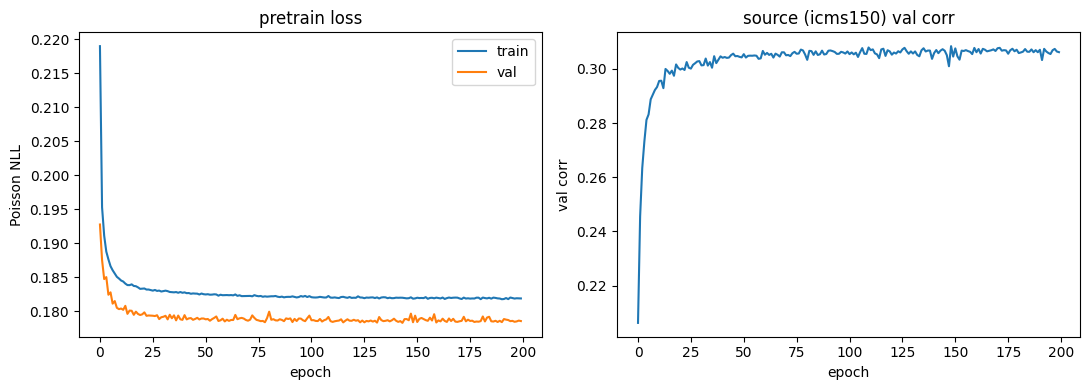

In [11]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(hist['train_loss'], label='train'); ax[0].plot(hist['val_loss'], label='val')
ax[0].set_xlabel('epoch'); ax[0].set_ylabel('Poisson NLL'); ax[0].legend(); ax[0].set_title('pretrain loss')
ax[1].plot(hist['val_corr']); ax[1].set_xlabel('epoch'); ax[1].set_ylabel('val corr')
ax[1].set_title(f"source ({CFG_XS['SOURCE']}) val corr")
plt.tight_layout(); plt.show()

## 2. Finetuning data-efficiency sweep

For each `N` in `FINETUNE_N_GRID`, each protocol, each seed, train a target
adapter+head (and optionally the backbone) on `N` target **non-oracle**
patterns, then evaluate on the target **held-out oracle** set.

- `frozen_backbone`: pretrained backbone frozen; fresh target adapter+head.
- `full_finetune`: pretrained backbone trainable; fresh target adapter+head.
- `from_scratch`: everything randomly re-initialized.

Reports **both** held-out Poisson NLL and correlation per run.

In [12]:
def sample_target_train_loader(target, n_patterns, cfg, seed):
    rng = np.random.RandomState(seed)
    pool = list(target['non_oracle_timing'])
    rng.shuffle(pool)
    chosen = pool[:n_patterns]
    ds = make_dataset(target, chosen, cfg, init_state=True)
    return make_loader(ds, cfg['BATCH_SIZE'], shuffle=True), len(chosen)

def init_model_for_protocol(protocol, target_key, pretrained_state, cfg):
    """Fresh CrossSessionSpikeCNN configured per protocol."""
    m = CrossSessionSpikeCNN(session_channels, session_neurons,
                             common_ch=cfg['COMMON_CH'], cfg=cfg).to(device)
    if protocol in ('frozen_backbone', 'full_finetune'):
        m.load_state_dict(pretrained_state)          # start from pretrained weights
        m.reset_session(target_key, session_neurons[target_key])  # fresh target adapter+head
        m.to(device)
        if protocol == 'frozen_backbone':
            m.freeze_backbone()
    # from_scratch: leave randomly initialized
    return m

def run_finetune_sweep(target_key, pretrained_state, cfg):
    assert target_key != 'icms148', "icms148 cannot be the eval target"
    target = sessions[target_key]
    eval_loader = make_loader(
        make_dataset(target, eval_timing_indices(target, cfg), cfg, init_state=True),
        cfg['BATCH_SIZE'], shuffle=False)

    rows = []
    for N in cfg['FINETUNE_N_GRID']:
        for protocol in cfg['PROTOCOLS']:
            for seed in cfg['SEEDS']:
                torch.manual_seed(seed); np.random.seed(seed)
                tr_loader, n_used = sample_target_train_loader(target, N, cfg, seed)
                m = init_model_for_protocol(protocol, target_key, pretrained_state, cfg)
                params = [p for p in m.parameters() if p.requires_grad]
                opt = torch.optim.Adam(params, lr=cfg['LR'], weight_decay=cfg['WEIGHT_DECAY'])
                for ep in range(cfg['FINETUNE_EPOCHS']):
                    train_one(m, tr_loader, target_key, opt, criterion, device)
                nll, corr = eval_one(m, eval_loader, target_key, criterion, device)
                rows.append(dict(N=N, n_used=n_used, protocol=protocol, seed=seed,
                                 eval_nll=nll, eval_corr=corr))
                print(f"N={N:>4} {protocol:<16} seed={seed}  NLL={nll:.4f}  corr={corr:.4f}")
    return pd.DataFrame(rows)

In [ ]:
# --- run the sweep (target = CFG_XS['TARGET']) ---
pretrained_state = torch.load(ckpt, map_location=device)
sweep_df = run_finetune_sweep(CFG_XS['TARGET'], pretrained_state, CFG_XS)
sweep_csv = os.path.join(run_dir, 'xs_sweep.csv')
sweep_df.to_csv(sweep_csv, index=False)
print('saved', sweep_csv)
sweep_df.head()

734 trials were added in spike responses for initial state that were not in the specified trial_indices
10 trials were added in spike responses for initial state that were not in the specified trial_indices
N=  10 frozen_backbone  seed=0  NLL=0.2768  corr=0.0468
10 trials were added in spike responses for initial state that were not in the specified trial_indices
N=  10 frozen_backbone  seed=1  NLL=0.2815  corr=0.0501
9 trials were added in spike responses for initial state that were not in the specified trial_indices
N=  10 frozen_backbone  seed=2  NLL=0.2773  corr=0.0511
10 trials were added in spike responses for initial state that were not in the specified trial_indices
N=  10 full_finetune    seed=0  NLL=0.2933  corr=0.0468
10 trials were added in spike responses for initial state that were not in the specified trial_indices
N=  10 full_finetune    seed=1  NLL=0.2956  corr=0.0470
9 trials were added in spike responses for initial state that were not in the specified trial_indices


## 3. Data-efficiency curves

NLL vs N and correlation vs N, one line per protocol (mean ± std over seeds).
Horizontal dashed line = source-on-source held-out reference (transfer
ceiling).

In [ ]:
def plot_sweep(sweep_df, src_nll, src_corr, cfg, save_dir=None):
    agg = (sweep_df.groupby(['protocol', 'N'])[['eval_nll', 'eval_corr']]
           .agg(['mean', 'std']).reset_index())
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    metrics = [('eval_nll', 'Poisson NLL (lower better)', src_nll, axes[0]),
               ('eval_corr', 'correlation (higher better)', src_corr, axes[1])]
    for metric, ylabel, ceiling, ax in metrics:
        for protocol in cfg['PROTOCOLS']:
            sub = agg[agg['protocol'] == protocol].sort_values('N')
            mean = sub[(metric, 'mean')].values
            std = np.nan_to_num(sub[(metric, 'std')].values)
            Ns = sub['N'].values
            ax.plot(Ns, mean, marker='o', label=protocol)
            ax.fill_between(Ns, mean - std, mean + std, alpha=0.2)
        ax.axhline(ceiling, ls='--', color='k', alpha=0.6,
                   label=f"source({cfg['SOURCE']}) held-out")
        ax.set_xscale('log'); ax.set_xlabel('# target finetune patterns (N)')
        ax.set_ylabel(ylabel); ax.legend(fontsize=8)
        ax.set_title(f"{ylabel.split(' ')[0]} vs N  ({cfg['SOURCE']}→{cfg['TARGET']})")
    plt.tight_layout()
    if save_dir:
        fig.savefig(os.path.join(save_dir, 'xs_data_efficiency.svg'), bbox_inches='tight')
        fig.savefig(os.path.join(save_dir, 'xs_data_efficiency.png'), dpi=150, bbox_inches='tight')
    plt.show()

plot_sweep(sweep_df, src_nll, src_corr, CFG_XS, save_dir=run_dir)

## 4. Native source vs. finetuned target — oracle held-out comparison

The fairest comparison available: evaluate the **pretrained source model** on the
**source** oracle set (native adapter + head) versus a **finetuned target model**
on the **target** oracle set (target adapter + head). The stimulation patterns
differ between sessions, but both oracle sets are *never* used in training, so
this isolates how close the transferred/finetuned model gets on the new session
to the source's native held-out performance.

The target model is finetuned at `COMPARE_N` (default: largest N in
`FINETUNE_N_GRID`) with `COMPARE_PROTOCOL` (default: best-by-correlation protocol
from the sweep), retrained once at seed 0 so the actual model stays in scope.

comparing finetuned target at N=3000, protocol=full_finetune
806 trials were added in spike responses for initial state that were not in the specified trial_indices
735 trials were added in spike responses for initial state that were not in the specified trial_indices
734 trials were added in spike responses for initial state that were not in the specified trial_indices
                                    model  session  oracle_nll  oracle_corr
                          source (native)  icms150    0.171524     0.301799
target (finetuned, N=3000, full_finetune) vis_stim    0.226304     0.262756


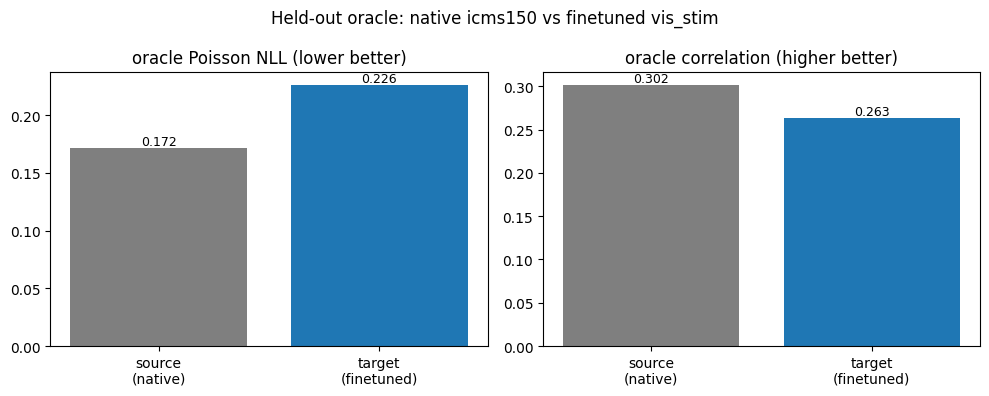

In [29]:
# --- native source vs. finetuned target on their own oracle sets ---
# pick the operating point to compare
COMPARE_N = max(CFG_XS["FINETUNE_N_GRID"])
COMPARE_PROTOCOL = (sweep_df[sweep_df.N == COMPARE_N]
                    .groupby("protocol")["eval_corr"].mean().idxmax())
print(f"comparing finetuned target at N={COMPARE_N}, protocol={COMPARE_PROTOCOL}")

# (1) SOURCE model on SOURCE oracle set, using source adapter+head.
#     `model` already holds the best pretrained weights; src_nll/src_corr were
#     computed on exactly this set during pretraining, but recompute for clarity.
src_eval_loader = make_loader(
    make_dataset(src, eval_timing_indices(src, CFG_XS), CFG_XS, init_state=True),
    CFG_XS["BATCH_SIZE"], shuffle=False)
src_oracle_nll, src_oracle_corr = eval_one(model, src_eval_loader, CFG_XS["SOURCE"],
                                           criterion, device)

# (2) TARGET model: retrain once at the chosen operating point, keep the model.
torch.manual_seed(0); np.random.seed(0)
tgt = sessions[CFG_XS["TARGET"]]
tgt_tr_loader, n_used = sample_target_train_loader(tgt, COMPARE_N, CFG_XS, seed=0)
tgt_model = init_model_for_protocol(COMPARE_PROTOCOL, CFG_XS["TARGET"],
                                    pretrained_state, CFG_XS)
opt = torch.optim.Adam([p for p in tgt_model.parameters() if p.requires_grad],
                       lr=CFG_XS["LR"], weight_decay=CFG_XS["WEIGHT_DECAY"])
for ep in range(CFG_XS["FINETUNE_EPOCHS"]):
    train_one(tgt_model, tgt_tr_loader, CFG_XS["TARGET"], opt, criterion, device)

tgt_eval_loader = make_loader(
    make_dataset(tgt, eval_timing_indices(tgt, CFG_XS), CFG_XS, init_state=True),
    CFG_XS["BATCH_SIZE"], shuffle=False)
tgt_oracle_nll, tgt_oracle_corr = eval_one(tgt_model, tgt_eval_loader,
                                           CFG_XS["TARGET"], criterion, device)

cmp = pd.DataFrame([
    dict(model="source (native)", session=CFG_XS["SOURCE"],
         oracle_nll=src_oracle_nll, oracle_corr=src_oracle_corr),
    dict(model=f"target (finetuned, N={COMPARE_N}, {COMPARE_PROTOCOL})",
         session=CFG_XS["TARGET"],
         oracle_nll=tgt_oracle_nll, oracle_corr=tgt_oracle_corr),
])
print(cmp.to_string(index=False))
cmp.to_csv(os.path.join(run_dir, "oracle_native_vs_finetuned.csv"), index=False)

# --- bar comparison ---
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
labels = ["source\n(native)", "target\n(finetuned)"]
for a, metric, title in [(ax[0], "oracle_nll", "oracle Poisson NLL (lower better)"),
                         (ax[1], "oracle_corr", "oracle correlation (higher better)")]:
    a.bar(labels, cmp[metric].values, color=["tab:gray", "tab:blue"])
    a.set_title(title)
    for i, v in enumerate(cmp[metric].values):
        a.text(i, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9)
fig.suptitle(f"Held-out oracle: native {CFG_XS['SOURCE']} vs finetuned {CFG_XS['TARGET']}")
plt.tight_layout()
fig.savefig(os.path.join(run_dir, "oracle_native_vs_finetuned.svg"), bbox_inches="tight")
fig.savefig(os.path.join(run_dir, "oracle_native_vs_finetuned.png"), dpi=150, bbox_inches="tight")
plt.show()

## 5. Temporal generalization — train on first TRAIN_MS, test overlap vs non-overlap

Self-contained single-session experiment (default session = `CFG_XS['SOURCE']`).
Train a plain `SimpleCausalSpikeCNN` to predict only the **first `TRAIN_MS`** of
each trial's response, then evaluate the session's **held-out oracle trials**
(never used in training) over the full window, comparing prediction error in the
**overlapping** period (`<= TRAIN_MS`, seen during training) vs the
**non-overlapping** period (`> TRAIN_MS`, never trained on).

The causal CNN's conv/FC are length-agnostic, so a model trained on
`TRAIN_BINS`-long inputs evaluates directly on the full window.

In [ ]:
# --- temporal-generalization config ---
from models import SimpleCausalSpikeCNN, train_epoch
from scipy.stats import pearsonr

SESSION_KEY = CFG_XS['SOURCE']       # which session to run on (must have oracles)
assert SESSION_KEY != 'icms148', "icms148 has no oracle trials"
assert len(sessions[SESSION_KEY]['oracle_timing']) > 0

TG = dict(
    TRAIN_MS = 300,                  # output-time-window split: ms of response used for training
    N_EPOCHS = CFG_XS['PRETRAIN_EPOCHS'],
)
FULL_MS = CFG_XS['MAX_TIME_MS']
OUT_BIN = CFG_XS['OUTPUT_BIN_MS']
assert TG['TRAIN_MS'] % OUT_BIN == 0 and FULL_MS % OUT_BIN == 0
TRAIN_BINS = TG['TRAIN_MS'] // OUT_BIN
FULL_BINS  = FULL_MS // OUT_BIN
assert 0 < TRAIN_BINS < FULL_BINS, "TRAIN_MS must be a strict prefix of the full window"
print(f"session={SESSION_KEY}  train={TG['TRAIN_MS']}ms ({TRAIN_BINS} bins)  "
      f"eval={FULL_MS}ms ({FULL_BINS} bins)  "
      f"overlap [0,{TRAIN_BINS}) vs non-overlap [{TRAIN_BINS},{FULL_BINS})")

sess = sessions[SESSION_KEY]
torch.manual_seed(CFG_XS['SEED']); np.random.seed(CFG_XS['SEED'])

def _windowed_ds(timing_indices, n_bins, time_ms):
    return BinnedStimSpikeDataset(
        pattern_df=sess['pattern_df'], spike_responses=sess['spike_responses'],
        channel_to_index=sess['channel_to_index'], timing_to_pattern=sess['timing_to_pattern'],
        trial_indices=timing_indices, encoding_mode=CFG_XS['ENCODING_MODE'],
        input_bin_size_ms=CFG_XS['INPUT_BIN_MS'], output_bin_size_ms=OUT_BIN,
        n_input_bins=n_bins, n_output_bins=n_bins,
        max_time_ms=time_ms, output_offset=0, init_state=False,
    )

# train on non-oracle trials (output truncated to TRAIN_MS); eval on full-window oracle trials
train_ds_tg = _windowed_ds(sess['non_oracle_timing'], TRAIN_BINS, TG['TRAIN_MS'])
test_ds_tg  = _windowed_ds(eval_timing_indices(sess, CFG_XS), FULL_BINS, FULL_MS)
train_loader_tg = make_loader(train_ds_tg, CFG_XS['BATCH_SIZE'], shuffle=True)
test_loader_tg  = make_loader(test_ds_tg, CFG_XS['BATCH_SIZE'], shuffle=False)
print(f"train samples {len(train_ds_tg)}  oracle-test samples {len(test_ds_tg)}")

# plain single-session model (stim-only, no embedding/init-state), causal conv
model_tg = SimpleCausalSpikeCNN(
    n_stim_channels=sess['n_stim_channels'], n_neurons=sess['n_neurons'],
    n_input_bins=TRAIN_BINS, n_output_bins=TRAIN_BINS,
    embedding_dim=1, conv_channels=CFG_XS['CONV_CHANNELS'],
    kernel_sizes=CFG_XS['KERNEL_SIZES'], fc_dims=CFG_XS['FC_DIMS'],
    dropout=CFG_XS['DROPOUT'], use_batch_norm=True, use_init_state=False,
).to(device)

opt_tg = torch.optim.Adam(model_tg.parameters(), lr=CFG_XS['LR'],
                          weight_decay=CFG_XS['WEIGHT_DECAY'])
for ep in range(1, TG['N_EPOCHS'] + 1):
    tl = train_epoch(model_tg, train_loader_tg, criterion, opt_tg, device,
                     grad_clip=True, max_norm=1.0)
    if ep % 10 == 0 or ep == 1:
        print(f"  epoch {ep:>3}/{TG['N_EPOCHS']}  train={tl:.4f}")

# --- eval full-window oracle trials, bucket per-bin error by time ---
model_tg.eval()
per_bin_nll = np.zeros(FULL_BINS); n_seen = 0
pred_by_bin = [[] for _ in range(FULL_BINS)]
true_by_bin = [[] for _ in range(FULL_BINS)]
with torch.no_grad():
    for bx, by in test_loader_tg:
        bx, by = bx.to(device), by.to(device)
        pred = model_tg(bx)                       # (B, n_neurons, FULL_BINS)
        nll = criterion(pred, by)
        per_bin_nll += nll.mean(dim=(0, 1)).cpu().numpy() * bx.size(0)
        n_seen += bx.size(0)
        rate = torch.exp(pred).cpu().numpy(); ytrue = by.cpu().numpy()
        for t in range(FULL_BINS):
            pred_by_bin[t].append(rate[:, :, t].ravel())
            true_by_bin[t].append(ytrue[:, :, t].ravel())
per_bin_nll /= n_seen
per_bin_corr = np.array([
    (pearsonr(np.concatenate(pred_by_bin[t]), np.concatenate(true_by_bin[t]))[0]
     if np.std(np.concatenate(true_by_bin[t])) > 0 else np.nan)
    for t in range(FULL_BINS)])

ov, no = slice(0, TRAIN_BINS), slice(TRAIN_BINS, FULL_BINS)
tg_summary = pd.DataFrame([
    dict(period='overlap (<=TRAIN_MS)',    bins=f'[0,{TRAIN_BINS})',
         mean_nll=np.nanmean(per_bin_nll[ov]), mean_corr=np.nanmean(per_bin_corr[ov])),
    dict(period='non-overlap (>TRAIN_MS)', bins=f'[{TRAIN_BINS},{FULL_BINS})',
         mean_nll=np.nanmean(per_bin_nll[no]), mean_corr=np.nanmean(per_bin_corr[no])),
])
print(f"\nOracle error by period (session={SESSION_KEY}, trained on first {TG['TRAIN_MS']} ms):")
print(tg_summary.to_string(index=False))
tg_summary.to_csv(os.path.join(run_dir, f'temporal_gen_{SESSION_KEY}_{TG["TRAIN_MS"]}ms.csv'), index=False)

# --- plots: per-period bars + per-bin error vs time with TRAIN_MS boundary ---
t_ms = (np.arange(FULL_BINS) + 0.5) * OUT_BIN
fig, ax = plt.subplots(2, 2, figsize=(12, 7))
ax[0,0].bar(tg_summary['period'], tg_summary['mean_nll'], color=['tab:blue','tab:red'])
ax[0,0].set_title('mean Poisson NLL by period (lower better)'); ax[0,0].tick_params(axis='x', rotation=12)
for i,v in enumerate(tg_summary['mean_nll']): ax[0,0].text(i, v, f'{v:.3f}', ha='center', va='bottom')
ax[0,1].bar(tg_summary['period'], tg_summary['mean_corr'], color=['tab:blue','tab:red'])
ax[0,1].set_title('mean correlation by period (higher better)'); ax[0,1].tick_params(axis='x', rotation=12)
for i,v in enumerate(tg_summary['mean_corr']): ax[0,1].text(i, v, f'{v:.3f}', ha='center', va='bottom')
ax[1,0].plot(t_ms, per_bin_nll, color='k'); ax[1,0].axvline(TG['TRAIN_MS'], ls='--', color='tab:red', label=f"TRAIN_MS={TG['TRAIN_MS']}")
ax[1,0].set_xlabel('time (ms)'); ax[1,0].set_ylabel('Poisson NLL'); ax[1,0].legend(); ax[1,0].set_title('per-bin oracle NLL vs time')
ax[1,1].plot(t_ms, per_bin_corr, color='k'); ax[1,1].axvline(TG['TRAIN_MS'], ls='--', color='tab:red', label=f"TRAIN_MS={TG['TRAIN_MS']}")
ax[1,1].set_xlabel('time (ms)'); ax[1,1].set_ylabel('correlation'); ax[1,1].legend(); ax[1,1].set_title('per-bin oracle correlation vs time')
fig.suptitle(f"Temporal generalization ({SESSION_KEY}): trained on first {TG['TRAIN_MS']} ms, "
             f"held-out oracle trials over {FULL_MS} ms")
plt.tight_layout()
fig.savefig(os.path.join(run_dir, f'temporal_gen_{SESSION_KEY}_{TG["TRAIN_MS"]}ms.png'), dpi=150, bbox_inches='tight')
plt.show()
